# Overfitting in Decision Trees


---

# 🌳 Chapter 6 — Overfitting in Decision Trees

## 🎭 Characters

👨‍🏫 **Professor Arjun**
👩 **Riya**
🤖 **Milo**

---

# 🌅 Classroom Scene

Riya asks:

> "Sir, our Decision Tree predicted perfectly for the training data.
> Does that mean it will always work perfectly?"

Professor Arjun smiles.

> "Not necessarily. Sometimes the model **memorizes the training data instead of learning patterns**."

This problem is called:

```text
Overfitting
```

---

# 🧠 Simple Meaning of Overfitting

Overfitting means:

```text
The model learns the training data TOO perfectly
```

But because of that, it performs **poorly on new data**.

---

# 🎯 Example

Suppose Milo sees this dataset.

| Hours Studied | Result |
| ------------- | ------ |
| 1             | Fail   |
| 2             | Fail   |
| 3             | Pass   |
| 4             | Pass   |
| 5             | Pass   |

A **simple tree** might learn this rule:

```text
If Hours < 2.5 → Fail
Else → Pass
```

This is **good learning**.

---

But suppose Milo builds a **very complicated tree** like this:

```text
If Hours < 1.3 → Fail
Else if Hours < 2.2 → Fail
Else if Hours < 3.1 → Pass
Else if Hours < 4.7 → Pass
Else → Pass
```

Now the tree becomes **too complex**.

It memorizes the dataset instead of learning general rules.

That is **Overfitting**.

---

# 📊 Visual Idea

### Good Tree

```text
Hours < 2.5 ?
      /     \
   Fail    Pass
```

Simple and understandable.

---

### Overfitted Tree

```text
Hours < 1.3 ?
Hours < 2.1 ?
Hours < 3.4 ?
Hours < 4.2 ?
Hours < 4.8 ?
```

Too many splits.

---

# 🤖 Why Overfitting Happens

Decision Trees naturally want to:

```text
Keep splitting until data becomes perfectly pure
```

But if we allow unlimited splits:

```text
The tree becomes too deep
```

---

# 🧠 Solution: Limit the Tree Depth

We control the tree using a parameter called:

```text
max_depth
```

Meaning:

```text
Maximum number of levels the tree can grow
```

---

# 🧪 Hands-On


We will train **two models**:

- 1️⃣ A **very deep tree** (overfitting)
- 2️⃣ A **limited depth tree** (better generalization)

# Step 1 — Import Libraries


In [ ]:
# Import numpy for working with numerical data
import numpy as np


# Import Decision Tree algorithm
from sklearn.tree import DecisionTreeClassifier


# Import library to visualize the tree
from sklearn.tree import plot_tree


# Import plotting library
import matplotlib.pyplot as plt



Explanation:

| Library                | Purpose        |
| ---------------------- | -------------- |
| numpy                  | Store data     |
| DecisionTreeClassifier | ML model       |
| plot_tree              | Visualize tree |
| matplotlib             | Draw graphs    |

---

# Step 2 — Create Dataset


In [7]:
# X represents input features
# In this example it is the number of hours studied

# Input feature (study hours)

X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8],
    [9],
    [10]
])

# y represents the results
# 0 = Fail
# 1 = Pass

y = np.array([
    0,
    0,
    1,
    0,
    1,
    1,
    0,
    1,
    1,
    1
])


Meaning:

| Student | Hours |
| ------- | ----- |
| 1       | 1     |
| 2       | 2     |
| 3       | 3     |
| 4       | 4     |
| 5       | 5     |
| 6       | 6     |
| 7       | 7     |
| 8       | 8     |

---

Now create labels.

Meaning:

Students studying **more hours usually pass**.

---

# Step 3 — Train a Very Deep Tree (Overfitting)


In [8]:
# Create a decision tree with NO limit on depth
# This allows the tree to grow as much as it wants

deep_tree = DecisionTreeClassifier(random_state=0)


# Train the model using the dataset
deep_tree.fit(X, y)

# The tree will keep splitting until it memorizes the dataset.


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

# Step 4 — Train a Controlled Tree


In [9]:
# Now we limit the depth.

# Create a decision tree with maximum depth = 2
# This prevents the tree from becoming too complex

simple_tree = DecisionTreeClassifier(max_depth=2, random_state=0)


# Train the model
simple_tree.fit(X, y)

# The tree can only have 2 levels. So it **cannot overfit easily**.


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

# Step 5 — Visualize the Tree


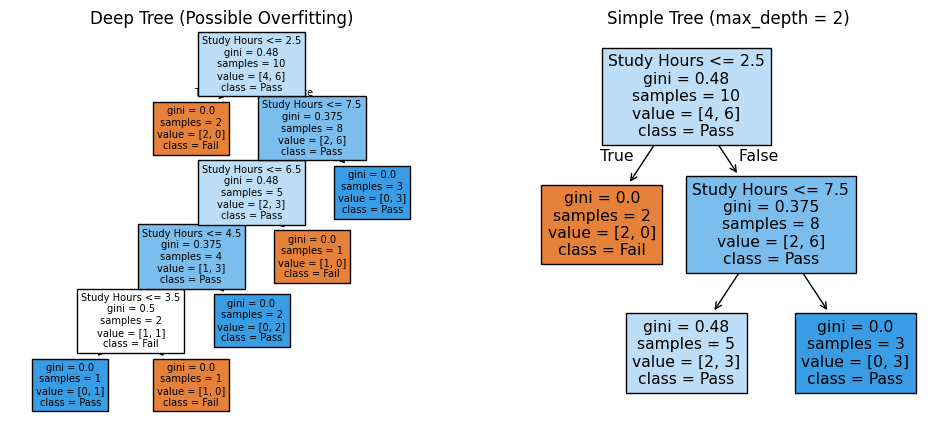

In [ ]:
# Create figure for visualization
plt.figure(figsize=(10,5))


# Draw the tree structure
plot_tree(deep_tree,
          feature_names=["Study Hours"],
          class_names=["Fail","Pass"],
          filled=True)


# Display the tree
plt.show()

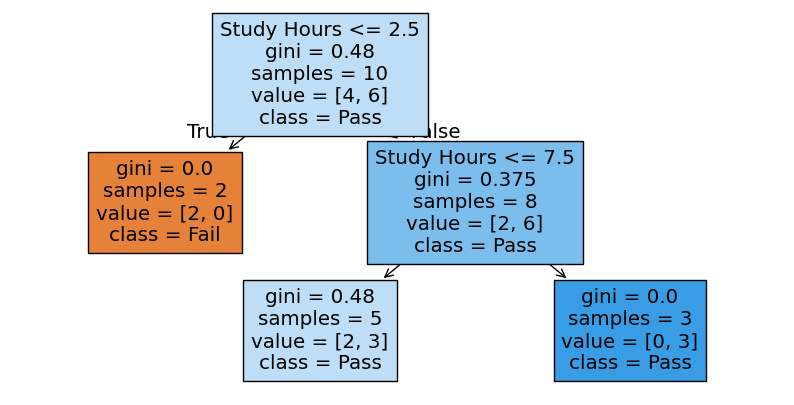

In [11]:
# Create figure for visualization
plt.figure(figsize=(10,5))


# Draw the tree structure
plot_tree(simple_tree,
          feature_names=["Study Hours"],
          class_names=["Fail","Pass"],
          filled=True)


# Display the tree
plt.show()

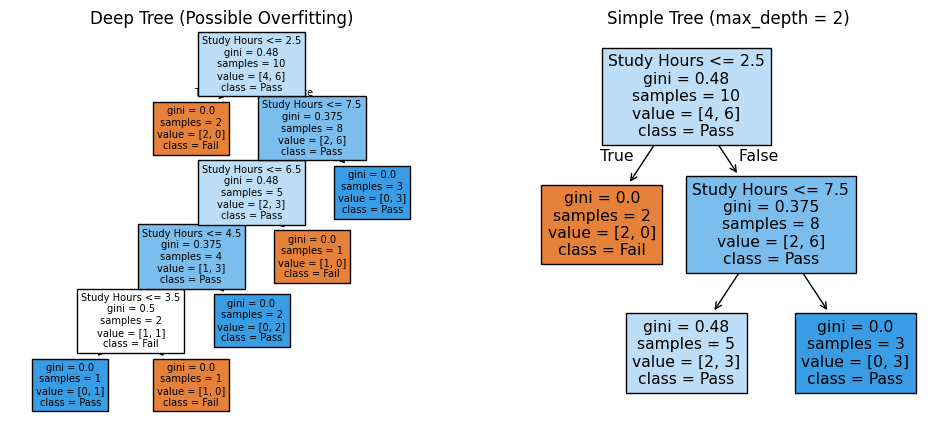

In [13]:
# Create a large figure with two subplots
plt.figure(figsize=(12,5))

# Plot the deep tree
plt.subplot(1,2,1)
plot_tree(
    deep_tree,
    feature_names=["Study Hours"],
    class_names=["Fail","Pass"],
    filled=True
)
plt.title("Deep Tree (Possible Overfitting)")


# Plot the simple tree
plt.subplot(1,2,2)
plot_tree(
    simple_tree,
    feature_names=["Study Hours"],
    class_names=["Fail","Pass"],
    filled=True
)
plt.title("Simple Tree (max_depth = 2)")


# Show the plots
plt.show()



# 🎯 What We Learned

✔ What **Overfitting** means
✔ Why **Decision Trees overfit easily**
✔ How **max_depth controls tree complexity**
✔ How to **train trees with different depths**

---

# 🧠 Real Machine Learning Engineers Always Tune

In real ML projects we control trees using:

```text
max_depth
min_samples_split
min_samples_leaf
max_leaf_nodes
```

These are called:

```text
Hyperparameters
```

---


